In [29]:
from pathlib import Path
import yaml
import os 
os.chdir(Path('/gpfs-calypso/home/globc/garcia/'))
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import glob
import numpy as np
import xarray as xr

from scenarIA.src.data.dataloader import get_climatology
from scenarIA.src.utils.evalutils import EvaluationPlots
from scenarIA.src.utils.datautils import dataset_xr_formatting, weighted_global_mean
from scenarIA.src.utils.settings import PREDICTIONS_DIR, DATASET_DIR, GRAPHS_DIR, CONFIG_DIR

In [32]:
clim = xr.open_dataset(DATASET_DIR / f'MPI-ESM1-2-LR/annual/outputs_piControl.nc').mean('member')
clim = clim.sel(time=slice('1850-01-01', '2250-12-31')).mean('time')
print(clim)

<xarray.Dataset> Size: 223kB
Dimensions:  (lat: 96, lon: 192)
Coordinates:
    height   float64 8B ...
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * lat      (lat) float64 768B -88.57 -86.72 -84.86 -83.0 ... 84.86 86.72 88.57
Data variables:
    tas      (lat, lon) float32 74kB 224.3 224.3 224.3 ... 255.8 255.8 255.8
    pr       (lat, lon) float64 147kB 0.1453 0.146 0.1468 ... 0.4773 0.4767


In [35]:
def plot_mean_std_simulations(files_dict,
                                var_name,
                                colors_dict=None,
                                vmin=None,
                                vmax=None,
                                time_res = 'Y',
                                title=None,
                                save_path=None):

    
    plt.figure(figsize=(6, 5)) 
    for simu, files in files_dict.items():
        if isinstance(files, str) or isinstance(files, Path):
            files = [files]
        color = colors_dict[simu] if colors_dict else None
        time = []
        mean = []
        std = []
        for file in files:
            if time_res == 'm':
                ds = xr.open_dataset(file, chunks= {'time':12})
                ds = dataset_xr_formatting(ds, original_time_format = "%Y%m")
                ds = ds[var_name].groupby('time.year').mean('time').rename({'year': 'time'})
        
            else:
                ds = xr.open_dataset(file)
                ds = dataset_xr_formatting(ds, original_time_format = "%Y")
                ds = ds[var_name]
            
            unit = ds.attrs["units"]       
            ds = ds - clim[var_name]
            ds = weighted_global_mean(ds)

            time.append(ds.time.values)
            if 'run' in ds.dims:
                mean.append(ds.mean('run').values)
                std.append(ds.std('run').values)
            else:
                mean.append(ds.values)
                std.append(np.zeros_like(ds.values))
            ds.close()
        time = np.concatenate(time)
        mean = np.concatenate(mean)
        std = np.concatenate(std)
        plt.plot(time, mean, label=f'Predictions mean {simu}', color=color, linestyle = '--', linewidth=1, alpha=0.6)
        plt.fill_between(time, mean - std, mean + std, alpha=0.2, color=color)

        # Add true simulation
        ds_true = xr.open_dataset(DATASET_DIR / f'MPI-ESM1-2-LR/annual/outputs_{simu}.nc')[var_name].mean('member') - clim[var_name]
        ds_true = weighted_global_mean(ds_true)
        plt.plot(time, ds_true.values , label=f'True {simu}', color=color, linewidth=2)

    plt.grid(axis='y', alpha = 0.5)
    plt.ylabel(f'{var_name} {unit}')
    plt.ylim(vmin, vmax)
    plt.legend(loc ='upper left')
    plt.title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)

{'ssp126': '/scratch/globc/garcia/scenarIA/predictions/MPI-ESM1-2-LR/annual/exp2/MPI-ESM1-2-LR_annual_exp2_ssp126_tas_cnn-lstm_seq10_mem30_sub1.nc', 'ssp245': '/scratch/globc/garcia/scenarIA/predictions/MPI-ESM1-2-LR/annual/exp1/MPI-ESM1-2-LR_annual_exp1_ssp245_tas_cnn-lstm_seq10_mem30_sub1.nc', 'ssp370': '/scratch/globc/garcia/scenarIA/predictions/MPI-ESM1-2-LR/annual/exp3/MPI-ESM1-2-LR_annual_exp3_ssp370_tas_cnn-lstm_seq10_mem30_sub1.nc', 'ssp585': '/scratch/globc/garcia/scenarIA/predictions/MPI-ESM1-2-LR/annual/exp4/MPI-ESM1-2-LR_annual_exp4_ssp585_tas_cnn-lstm_seq10_mem30_sub1.nc'}


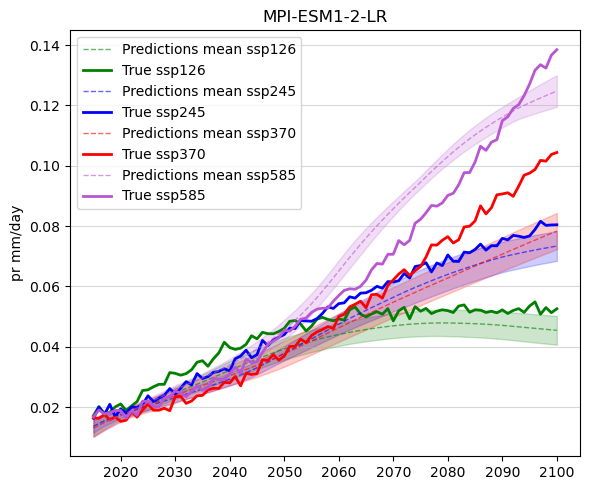

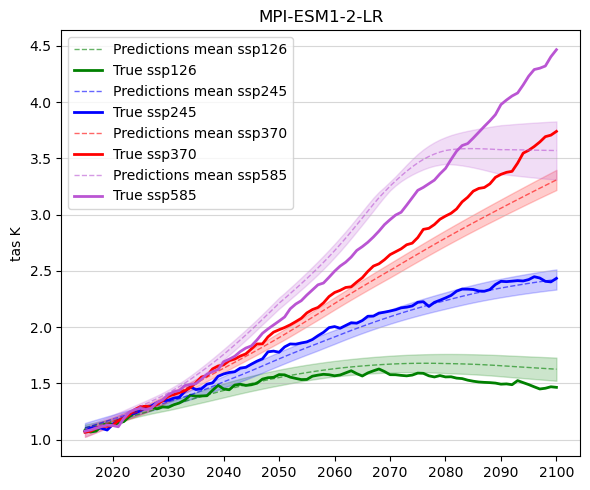

In [36]:
simus = ['ssp126', 'ssp245', 'ssp370', 'ssp585']
files_dict = {}
colors_dict = {'ssp126': 'green', 
              'ssp245': 'b', 
              'ssp370':'r', 
              'ssp585': 'mediumorchid'}
vmin = {'tas': None, 'pr': None}
vmax = {'tas': None, 'pr': None}
for var_name in ['pr', 'tas']:
    for simu in simus:
        files_dict[simu] = glob.glob(str(PREDICTIONS_DIR / f'MPI-ESM1-2-LR/annual/*/*{simu}_{var_name}*.nc'))[0]
    plot_mean_std_simulations(files_dict,
                              var_name=var_name,
                              colors_dict = colors_dict,
                              title='MPI-ESM1-2-LR',
                              vmin=vmin[var_name],
                              vmax=vmax[var_name],
                              save_path= GRAPHS_DIR / f'runs/MPI-ESM1-2-LR/annual/{var_name}_temporal_profiles_cross_validation.png'
                              )
print(files_dict)

{'tas': {'shortname': 'tas', 'longname': 'Temperature', 'unit': 'K', 'lim': {'values': [-12, 12], 'rmse': [0.0, 1.1], 'mae': [0.0, 1.5], 'temporal_correlation': [-1, 1], 'mean_error': [-2, 2], 'error': [-0.9, 0.9], 'relative_changes': [0.0, 4.5], 'relative_error': [-0.5, 0.5], 'std': [0.0, 0.5]}, 'color': 'red', 'cmap': {'values': 'coolwarm', 'rmse': 'Reds', 'mae': 'viridis', 'temporal_correlation': 'coolwarm', 'mean_error': 'coolwarm', 'error': 'coolwarm', 'relative_changes': 'Reds', 'relative_error': 'coolwarm', 'std': 'Reds'}}, 'pr': {'shortname': 'pr', 'longname': 'Precipitation', 'unit': 'mm/day', 'lim': {'values': [-2.5, 2.5], 'rmse': [0.0, 0.8], 'mae': [0, 2.5], 'temporal_correlation': [-1, 1], 'mean_error': [-1.6, 1.6], 'error': [-0.6, 0.6], 'relative_error': [-0.6, 0.6], 'std': [0.0, 0.3]}, 'color': 'c', 'cmap': {'values': 'BrBG', 'rmse': 'Reds', 'mae': 'viridis', 'temporal_correlation': 'coolwarm', 'mean_error': 'coolwarm', 'error': 'coolwarm', 'relative_error': 'coolwarm', '

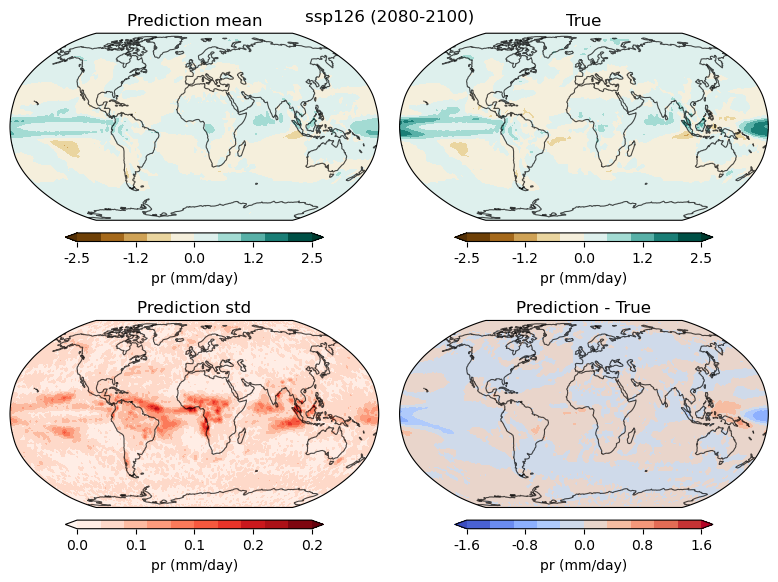

evalllll
(96, 192)
(96, 192)
(96, 192)
(96, 192)


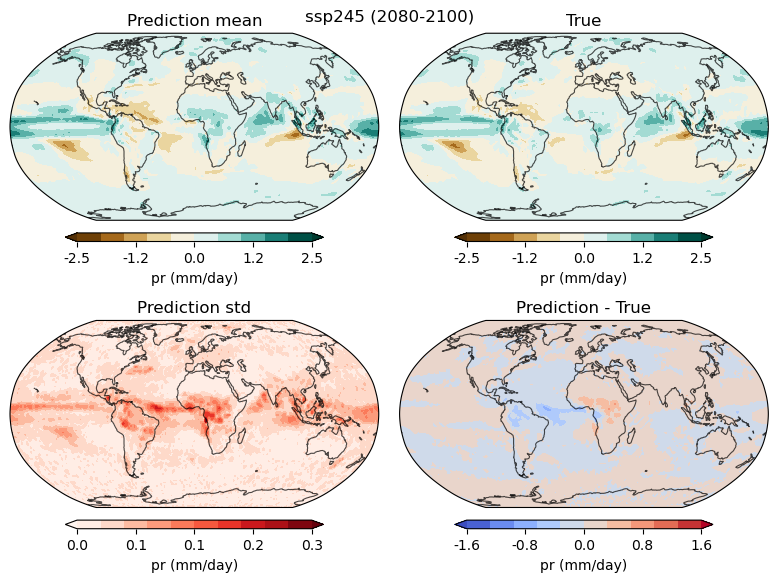

evalllll
(96, 192)
(96, 192)
(96, 192)
(96, 192)


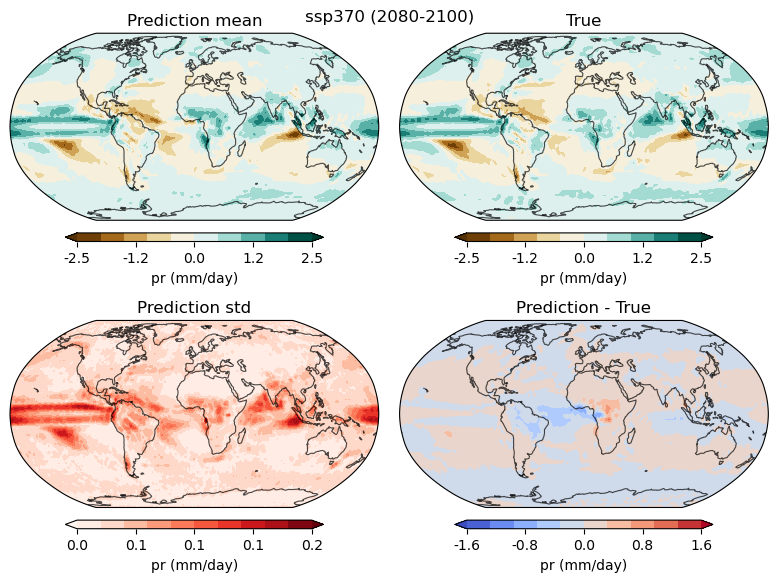

evalllll
(96, 192)
(96, 192)
(96, 192)
(96, 192)


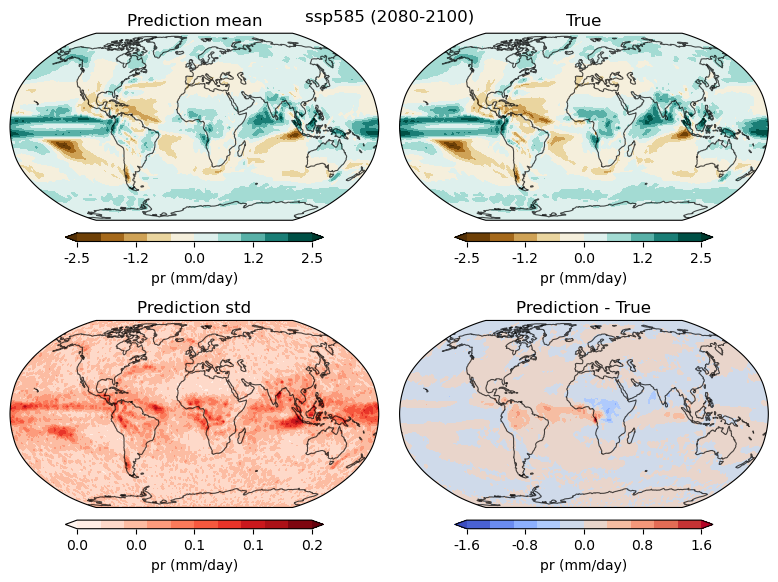

evalllll
(96, 192)
(96, 192)
(96, 192)
(96, 192)


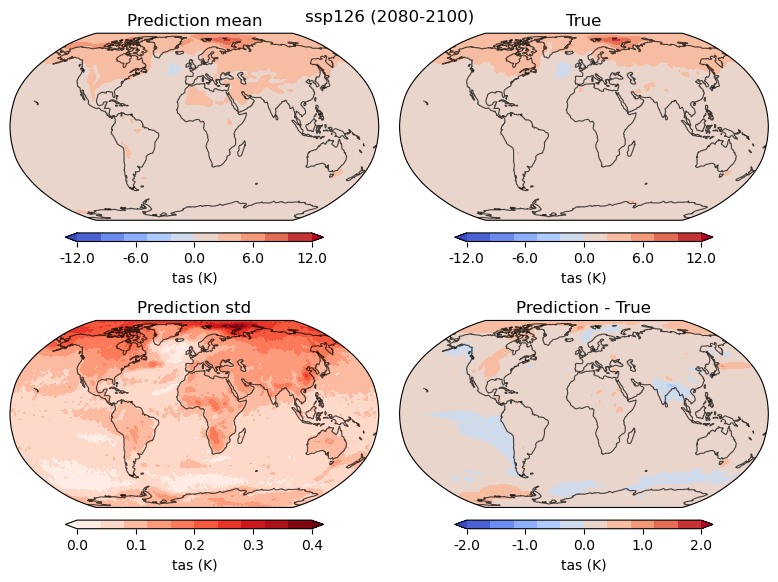

evalllll
(96, 192)
(96, 192)
(96, 192)
(96, 192)


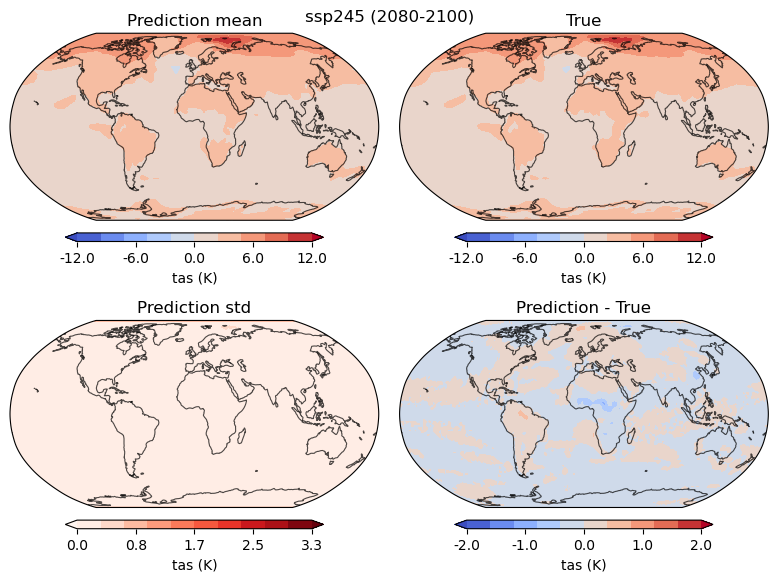

evalllll
(96, 192)
(96, 192)
(96, 192)
(96, 192)


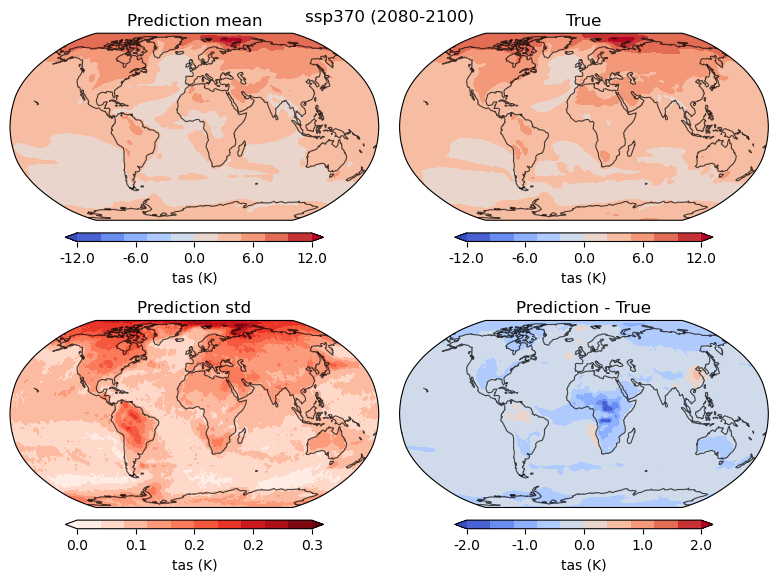

evalllll
(96, 192)
(96, 192)
(96, 192)
(96, 192)


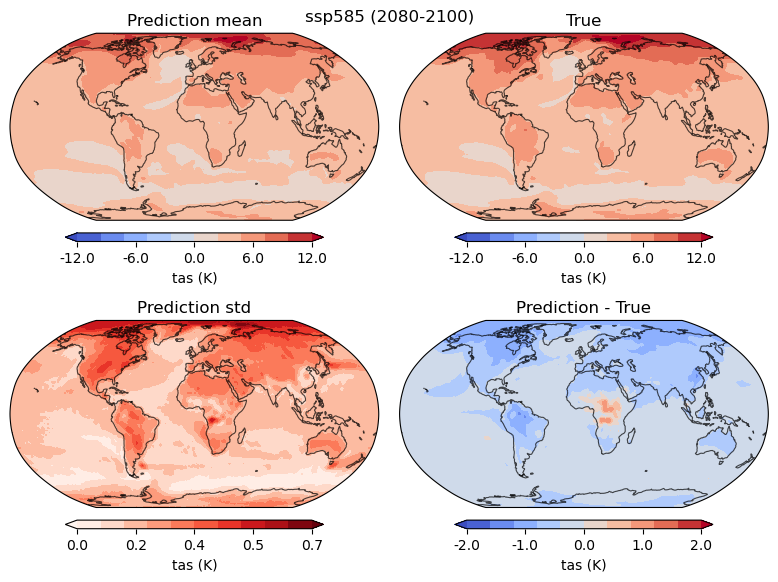

In [45]:

with open(CONFIG_DIR / 'plots.yaml') as file:
    config_plots = yaml.safe_load(file)
    
config_plots['tas']['lim']['mean_error'] = [-2,2]
config_plots['tas']['lim']['values'] = [-12, 12]
config_plots['pr']['lim']['mean_error'] = [-1.6,1.6]
config_plots['pr']['lim']['values'] = [-2.5, 2.5]
print(config_plots)

for var_name in ['pr', 'tas']:
    for simu in simus:
        files_dict[simu] = glob.glob(str(PREDICTIONS_DIR / f'MPI-ESM1-2-LR/annual/*/*{simu}_{var_name}*.nc'))[0]
        eval_func = EvaluationPlots(config_plots=config_plots,
                                        simulation_name=simu,
                                        var_name=var_name)
        y = xr.open_dataset(DATASET_DIR / f'MPI-ESM1-2-LR/annual/outputs_{simu}.nc')[var_name].mean('member').sel(time=slice('2080', '2100')).values
        y_hat = xr.open_dataset(files_dict[simu])[var_name].sel(time=slice('2080', '2100')) - clim[var_name]
                                                                                                                  
        eval_func.plot_diff_maps(y - clim[var_name].values, 
                                y_hat.mean('run').values, 
                                y_hat.std('run').values, 
                                title=f'{simu} (2080-2100)',
                                 no_limits=False,
                                save_path=None)